In [18]:
import os, glob

RUN_DIR = "../fine_tune/full_finetuning/lr5e-5"

print("RUN_DIR exists:", os.path.isdir(RUN_DIR))
pattern = os.path.join(RUN_DIR, "**", "checkpoint-*", "trainer_state.json")
paths = sorted(glob.glob(pattern, recursive=True))

print("trainer_state.json files found:", len(paths))
for p in paths[:5]:
    print(" -", p)
if len(paths) > 5:
    print(" ...")
    print(" -", paths[-1])

RUN_DIR exists: True
trainer_state.json files found: 3
 - ../fine_tune/full_finetuning/lr5e-5/checkpoint-36091/trainer_state.json
 - ../fine_tune/full_finetuning/lr5e-5/checkpoint-40337/trainer_state.json
 - ../fine_tune/full_finetuning/lr5e-5/checkpoint-42460/trainer_state.json


In [19]:
import json, re
import pandas as pd

def step_from_ckpt_path(p: str) -> int:
    m = re.search(r"checkpoint-(\d+)", p)
    return int(m.group(1)) if m else -1

eval_rows = []

for p in paths:
    ckpt_step = step_from_ckpt_path(p)
    with open(p, "r") as f:
        st = json.load(f)
    for h in st.get("log_history", []):
        if "eval_loss" in h:
            row = dict(h)
            row["_ckpt_step_folder"] = ckpt_step
            row["_trainer_state_path"] = p
            eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows)

print("Eval entries found:", len(eval_df))
if len(eval_df):
    print("Eval columns:", list(eval_df.columns))
    eval_df.head(5)


Eval entries found: 56
Eval columns: ['epoch', 'eval_dice', 'eval_iou', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'step', '_ckpt_step_folder', '_trainer_state_path']


In [20]:
if len(eval_df) == 0:
    raise RuntimeError("No eval logs found. That means evaluation didn't run (or eval_loss never got logged).")

eval_df["step"] = pd.to_numeric(eval_df["step"], errors="coerce")
eval_df["epoch"] = pd.to_numeric(eval_df["epoch"], errors="coerce")

eval_df = (eval_df
           .dropna(subset=["step"])
           .sort_values("step")
           .drop_duplicates(subset=["step"], keep="last")
           .reset_index(drop=True))

print("Unique eval steps:", len(eval_df))
eval_df.tail(5)


Unique eval steps: 20


,epoch,eval_dice,eval_iou,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,step,_ckpt_step_folder,_trainer_state_path
15,16.0,0.499442,0.566695,0.307334,17.1262,124.955,0.993,33968,36091,../fine_tune/full_finetuning/lr5e-5/checkpoint...
16,17.0,0.499975,0.572738,0.308136,17.1468,124.805,0.991,36091,42460,../fine_tune/full_finetuning/lr5e-5/checkpoint...
17,18.0,0.500384,0.565983,0.309519,17.2021,124.403,0.988,38214,42460,../fine_tune/full_finetuning/lr5e-5/checkpoint...
18,19.0,0.500510,0.570397,0.309720,17.2202,124.272,0.987,40337,40337,../fine_tune/full_finetuning/lr5e-5/checkpoint...
19,20.0,0.500756,0.569193,0.308531,17.2777,123.859,0.984,42460,42460,../fine_tune/full_finetuning/lr5e-5/checkpoint...


In [31]:
import os

def guess_checkpoint_path(run_dir: str, step: int) -> str:
    cand = os.path.join(run_dir, f"checkpoint-{int(step)}")
    return cand if os.path.isdir(cand) else "(checkpoint folder not found for this step)"

def best_by(col: str, mode: str = "max"):
    if col not in eval_df.columns:
        return None
    s = pd.to_numeric(eval_df[col], errors="coerce")
    tmp = eval_df.copy()
    tmp[col] = s
    tmp = tmp.dropna(subset=[col])
    if len(tmp) == 0:
        return None
    idx = tmp[col].idxmax() if mode == "max" else tmp[col].idxmin()
    return tmp.loc[idx]

best = None
metric_used = None

for col, mode in [("eval_iou", "max"), ("eval_dice", "max"), ("eval_loss", "min")]:
    r = best_by(col, mode)
    if r is not None:
        best = r
        metric_used = (col, mode)
        break

print("Metric used:", metric_used)
print("\n=== BEST CHECKPOINT ===")
print("step :", int(best['step']))
print("epoch:", float(best['epoch']) if pd.notna(best["epoch"]) else None)

for k in ["eval_iou", "eval_dice", "eval_loss"]:
    if k in best and pd.notna(best[k]):
        print(f"{k}: {best[k]}")

print("\nCheckpoint folder:", guess_checkpoint_path(RUN_DIR, best["step"]))
print("Logged in file   :", best["_trainer_state_path"])


Metric used: ('eval_iou', 'max')

=== BEST CHECKPOINT ===
step : 36091
epoch: 17.0
eval_iou: 0.5727376937866211
eval_dice: 0.4999745488166809
eval_loss: 0.3081359267234802

Checkpoint folder: ../fine_tune/full_finetuning/lr5e-5/checkpoint-36091
Logged in file   : ../fine_tune/full_finetuning/lr5e-5/checkpoint-42460/trainer_state.json


In [23]:
import json
import re
import pandas as pd


def step_from_ckpt_path(p: str) -> int:
    m = re.search(r"checkpoint-(\d+)", p)
    return int(m.group(1)) if m else -1


def load_from_path(trainer_state_path: str):
    train_rows = []
    eval_rows  = []


    ckpt_step = step_from_ckpt_path(trainer_state_path)
    with open(trainer_state_path, "r") as f:
        st = json.load(f)


    for h in st.get("log_history", []):
        if "step" not in h:
            continue


        if "loss" in h and "eval_loss" not in h:
            r = dict(h)
            r["_ckpt_step_folder"] = ckpt_step
            r["_trainer_state_path"] = trainer_state_path
            train_rows.append(r)


        if "eval_loss" in h:
            r = dict(h)
            r["_ckpt_step_folder"] = ckpt_step
            r["_trainer_state_path"] = trainer_state_path
            eval_rows.append(r)


    train_df = pd.DataFrame(train_rows)
    eval_df  = pd.DataFrame(eval_rows)


    print("Train entries:", len(train_df))
    print("Eval entries :", len(eval_df))


    for col in ["step", "epoch", "loss", "learning_rate"]:
        if col in train_df.columns:
            train_df[col] = pd.to_numeric(train_df[col], errors="coerce")


    for col in ["step", "epoch", "eval_loss", "eval_iou", "eval_dice"]:
        if col in eval_df.columns:
            eval_df[col] = pd.to_numeric(eval_df[col], errors="coerce")


    train_df = (train_df.dropna(subset=["step", "loss"])
                .sort_values("step")
                .drop_duplicates(subset=["step"], keep="last")
                .reset_index(drop=True))


    eval_df = (eval_df.dropna(subset=["step", "eval_loss"])
               .sort_values("step")
               .drop_duplicates(subset=["step"], keep="last")
               .reset_index(drop=True))


    print("Unique train steps:", len(train_df), "| range:",
          int(train_df.step.min()), "→", int(train_df.step.max()))
    print("Unique eval  steps:", len(eval_df),  "| range:",
          int(eval_df.step.min()),  "→", int(eval_df.step.max()))


    return train_df, eval_df


train_df, eval_df = load_from_path("../fine_tune/full_finetuning/lr5e-5/checkpoint-42460/trainer_state.json")


Train entries: 849
Eval entries : 20
Unique train steps: 849 | range: 50 → 42450
Unique eval  steps: 20 | range: 2123 → 42460


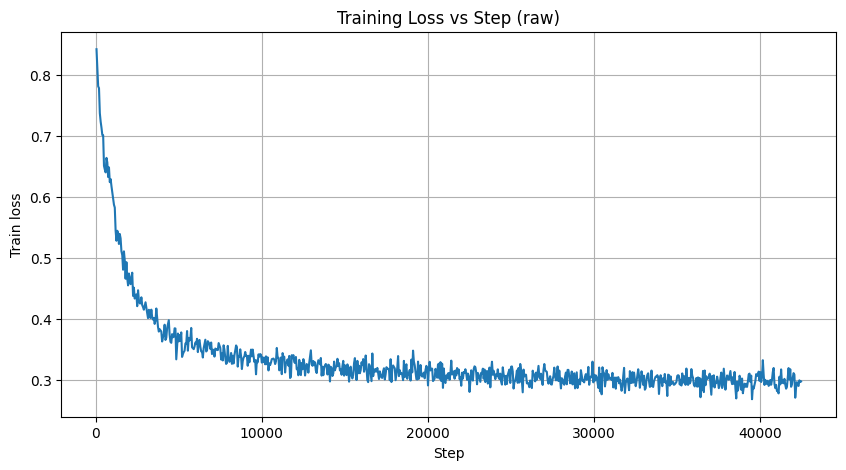

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_df["step"], train_df["loss"])
plt.xlabel("Step")
plt.ylabel("Train loss")
plt.title("Training Loss vs Step (raw)")
plt.grid(True)
plt.show()

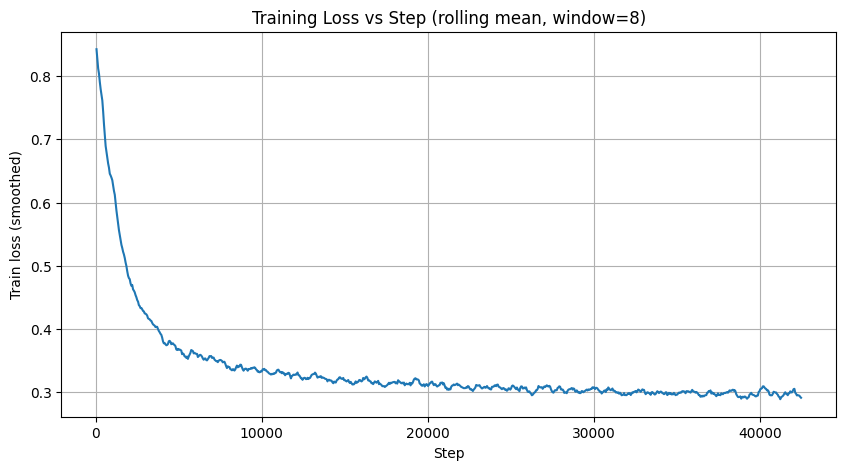

In [25]:
WINDOW = 8

train_df["loss_smooth"] = train_df["loss"].rolling(WINDOW, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(train_df["step"], train_df["loss_smooth"])
plt.xlabel("Step")
plt.ylabel("Train loss (smoothed)")
plt.title(f"Training Loss vs Step (rolling mean, window={WINDOW})")
plt.grid(True)
plt.show()


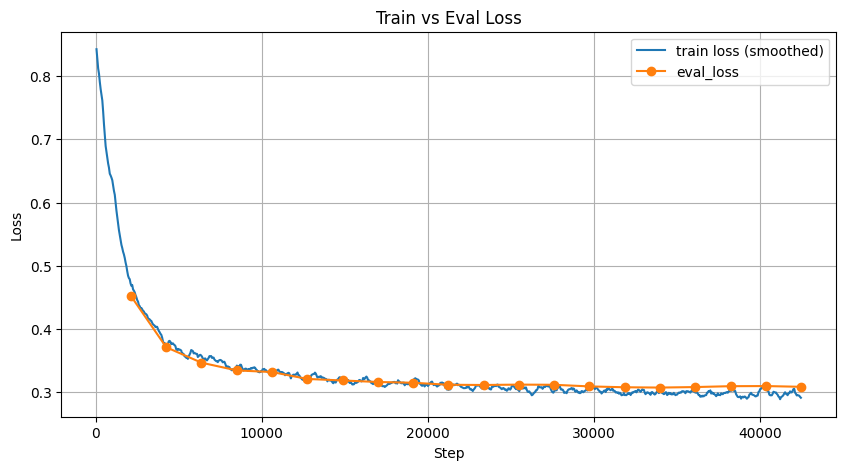

In [26]:
plt.figure(figsize=(10,5))
plt.plot(train_df["step"], train_df["loss_smooth"], label="train loss (smoothed)")
plt.plot(eval_df["step"], eval_df["eval_loss"], marker="o", label="eval_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train vs Eval Loss")
plt.grid(True)
plt.legend()
plt.show()

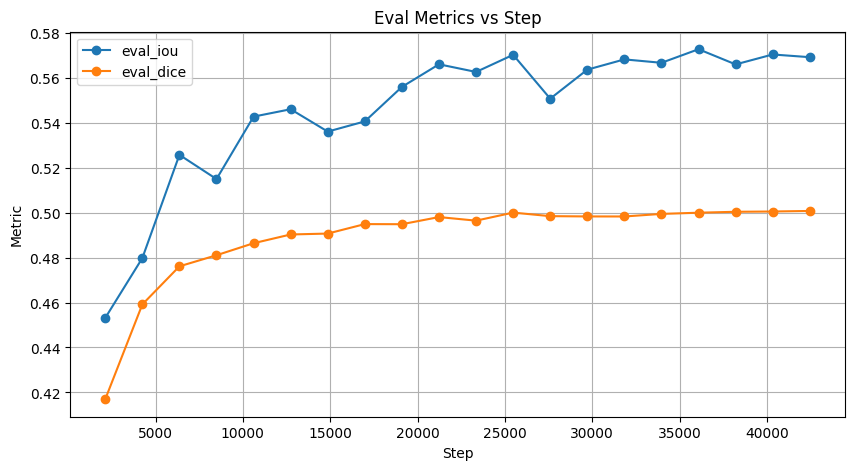

In [27]:
plt.figure(figsize=(10,5))

if "eval_iou" in eval_df.columns and eval_df["eval_iou"].notna().any():
    plt.plot(eval_df["step"], eval_df["eval_iou"], marker="o", label="eval_iou")

if "eval_dice" in eval_df.columns and eval_df["eval_dice"].notna().any():
    plt.plot(eval_df["step"], eval_df["eval_dice"], marker="o", label="eval_dice")

plt.xlabel("Step")
plt.ylabel("Metric")
plt.title("Eval Metrics vs Step")
plt.grid(True)
plt.legend()
plt.show()

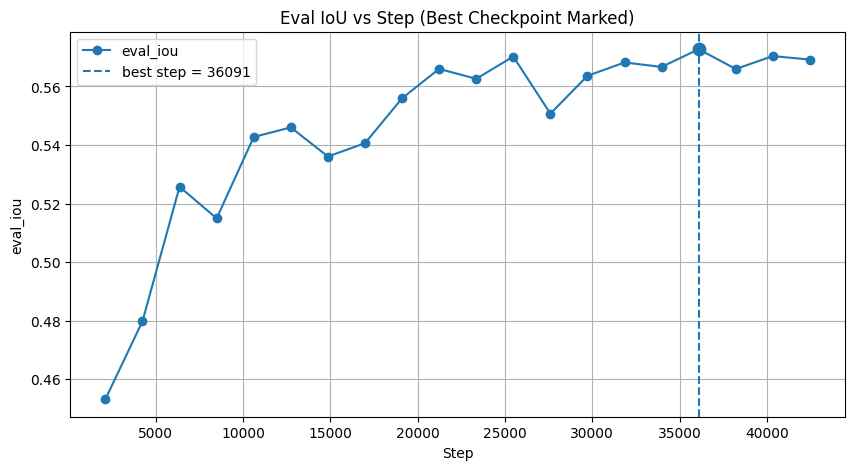

Best step: 36091
Best eval_iou: 0.5727376937866211


In [28]:
if "eval_iou" in eval_df.columns and eval_df["eval_iou"].notna().any():
    best_row = eval_df.loc[eval_df["eval_iou"].idxmax()]
    best_step = int(best_row["step"])
    best_iou = float(best_row["eval_iou"])

    plt.figure(figsize=(10,5))
    plt.plot(eval_df["step"], eval_df["eval_iou"], marker="o", label="eval_iou")
    plt.axvline(best_step, linestyle="--", label=f"best step = {best_step}")
    plt.scatter([best_step], [best_iou], s=80)
    plt.xlabel("Step")
    plt.ylabel("eval_iou")
    plt.title("Eval IoU vs Step (Best Checkpoint Marked)")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Best step:", best_step)
    print("Best eval_iou:", best_iou)